# trangram

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["VECLIB_MAXIMUM_THREADS"] = "4"  # for Apple Accelerate
os.environ["NUMEXPR_NUM_THREADS"] = "4"
os.environ["OMP_MAX_ACTIVE_LEVELS"] = "1"   # replaces deprecated omp_set_nested
# Optional safety:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # only if you still crash

# Now import
import scanpy as sc

In [2]:
import tangram as tg
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

'releases/20250531/manifest.json'

In [3]:
cluster = abc_cache.get_metadata_dataframe(directory='WMB-taxonomy', file_name='cluster')
print(len(cluster))
cluster.head(5)

5322


,cluster_alias,number_of_cells,label
0,1,727,CS20230722_0001
1,10,740,CS20230722_0010
2,100,1053,CS20230722_0100
3,1000,59,CS20230722_1000
4,1001,96,CS20230722_1001


In [4]:
term_set = abc_cache.get_metadata_dataframe(directory='WMB-taxonomy', file_name='cluster_annotation_term_set')
term_set

,label,name,description,order
0,CCN20230722_NEUR,neurotransmitter,Clusters are assigned based on the average exp...,0
1,CCN20230722_CLAS,class,The top level of cell type definition in the m...,1
2,CCN20230722_SUBC,subclass,The coarse level of cell type definition in th...,2
3,CCN20230722_SUPT,supertype,The second finest level of cell type definitio...,3
4,CCN20230722_CLUS,cluster,The finest level of cell type definition in th...,4


In [5]:
membership = abc_cache.get_metadata_dataframe(directory='WMB-taxonomy', file_name='cluster_to_cluster_annotation_membership')
membership.head(5)

,cluster_annotation_term_label,cluster_annotation_term_set_label,cluster_alias,cluster_annotation_term_name,cluster_annotation_term_set_name,number_of_cells,color_hex_triplet
0,CS20230722_CLUS_0001,CCN20230722_CLUS,128,0001 CLA-EPd-CTX Car3 Glut_1,cluster,4262,#00664E
1,CS20230722_CLUS_0002,CCN20230722_CLUS,129,0002 CLA-EPd-CTX Car3 Glut_1,cluster,3222,#5C79CC
2,CS20230722_CLUS_0003,CCN20230722_CLUS,130,0003 CLA-EPd-CTX Car3 Glut_1,cluster,12216,#86FF4D
3,CS20230722_CLUS_0004,CCN20230722_CLUS,143,0004 CLA-EPd-CTX Car3 Glut_1,cluster,9334,#CC563D
4,CS20230722_CLUS_0005,CCN20230722_CLUS,131,0005 CLA-EPd-CTX Car3 Glut_2,cluster,1056,#E7FF26


In [6]:
pivot = membership.groupby(['cluster_alias', 'cluster_annotation_term_set_name'])['cluster_annotation_term_name'].first().unstack()
pivot = pivot[term_set['name']] # order columns
pivot

cluster_annotation_term_set_name,neurotransmitter,class,subclass,supertype,cluster
cluster_alias,,,,,
1,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0326 L2 IT PPP-APr Glut_3
2,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0082 L2 IT PPP-APr Glut_3,0327 L2 IT PPP-APr Glut_3
3,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0322 L2 IT PPP-APr Glut_2
4,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0323 L2 IT PPP-APr Glut_2
5,Glut,01 IT-ET Glut,018 L2 IT PPP-APr Glut,0081 L2 IT PPP-APr Glut_2,0325 L2 IT PPP-APr Glut_2
...,...,...,...,...,...
34368,GABA-Glyc,27 MY GABA,288 MDRN Hoxb5 Ebf2 Gly-Gaba,1102 MDRN Hoxb5 Ebf2 Gly-Gaba_1,4955 MDRN Hoxb5 Ebf2 Gly-Gaba_1
34372,GABA-Glyc,27 MY GABA,285 MY Lhx1 Gly-Gaba,1091 MY Lhx1 Gly-Gaba_3,4901 MY Lhx1 Gly-Gaba_3
34374,GABA-Glyc,27 MY GABA,285 MY Lhx1 Gly-Gaba,1091 MY Lhx1 Gly-Gaba_3,4902 MY Lhx1 Gly-Gaba_3


In [7]:
ad_sc = sc.read_h5ad('/Users/christoffer/work/karolinska/development/data/abc_atlas/expression_matrices/WMB-10Xv2/20230630/WMB-10Xv2-MB-raw.h5ad')
meta = pd.read_csv('/Users/christoffer/work/karolinska/development/data/abc_atlas/metadata/WMB-10X/20241115/cell_metadata.csv')

In [21]:
ad_sc.write('/Users/christoffer/work/karolinska/development/data/abc_atlas/expression_matrices/WMB-10Xv2/20230630/WMB-10Xv2-MB-raw_with_meta.h5ad')

In [8]:
ad_sc.obs['cluster_alias'] = ad_sc.obs['cell_barcode'].map(dict(zip(meta.cell_barcode, meta.cluster_alias)))

In [9]:
ad_sc.obs

,cell_barcode,library_label,anatomical_division_label,cluster_alias
cell_label,,,,
CGGGTCAGTTAGTGGG-059_E01,CGGGTCAGTTAGTGGG,L8TX_181011_01_F02,MB,224.0
CGCGTTTGTCTAGGTT-067_B01,CGCGTTTGTCTAGGTT,L8TX_181116_01_B11,MB,14939.0
GAATAAGGTGCAGACA-059_E01,GAATAAGGTGCAGACA,L8TX_181011_01_F02,MB,3268.0
CCTCTGAGTAATAGCA-059_C01,CCTCTGAGTAATAGCA,L8TX_181011_01_E02,MB,171.0
TTGAACGTCAGTTCGA-059_D01,TTGAACGTCAGTTCGA,L8TX_181011_01_F03,MB,4993.0
...,...,...,...,...
CCTTCCCAGTCGATAA-066_A01,CCTTCCCAGTCGATAA,L8TX_181116_01_H10,MB,5254.0
GCAGCCAAGTTTCCTT-066_A01,GCAGCCAAGTTTCCTT,L8TX_181116_01_H10,MB,5254.0
TAAGCGTGTCTTGATG-066_A01,TAAGCGTGTCTTGATG,L8TX_181116_01_H10,MB,5254.0


In [10]:
ad_sc = ad_sc[~ad_sc.obs['cluster_alias'].isna()]

In [11]:
ad_sc.obs['cluster_alias'] = ad_sc.obs['cluster_alias'].dropna().astype(int)

In [12]:
ad_sc.obs['class'] = ad_sc.obs['cluster_alias'].map(dict(zip(pivot.index,pivot['class'])))

In [13]:
ad_sc.X.max()

np.float32(3174.0)

In [14]:
ad_sp = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')

In [15]:
ad_sp.X = ad_sp.layers['counts']

In [16]:
ad_sp.X.max()

np.int64(16903)

In [17]:
ad_sc.X.max()

np.float32(3174.0)

In [18]:
ad_sc.X = ad_sc.X.astype(int)

In [ ]:
sc.pp.normalize_total(ad_sc, target_sum=1e4)

In [19]:
sc.pp.normalize_total(ad_sp, target_sum=1e4)

In [39]:
sc.pp.log1p(ad_sc)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [40]:
sc.pp.normalize_total(ad_sp, target_sum=1e4)
sc.pp.log1p(ad_sp)

In [45]:
sc.pp.highly_variable_genes(
    ad_sc,
    flavor='seurat_v3',     # modern, robust method
    n_top_genes=1000,       # number of top variable genes to keep
    batch_key=None          # add if you want to correct for batch effects
)

In [52]:
genes = ad_sc.var['highly_variable']

In [57]:
ad_sc.var

,gene_symbol,highly_variable,highly_variable_rank,means,variances,variances_norm
gene_identifier,,,,,,
ENSMUSG00000051951,Xkr4,False,NaN,1.284285,0.615678,1.013488
ENSMUSG00000089699,Gm1992,False,NaN,0.082508,0.067204,0.942757
ENSMUSG00000102331,Gm19938,False,NaN,0.256103,0.192360,0.959893
ENSMUSG00000102343,Gm37381,False,NaN,0.000457,0.000450,1.062918
ENSMUSG00000025900,Rp1,False,NaN,0.002352,0.002091,0.928185
...,...,...,...,...,...,...
ENSMUSG00000095523,AC124606.1,False,NaN,0.000000,0.000000,0.000000
ENSMUSG00000095475,AC133095.2,False,NaN,0.000000,0.000000,0.000000
ENSMUSG00000094855,AC133095.1,False,NaN,0.000000,0.000000,0.000000


In [58]:
ad_sc.var_names = ad_sc.var.gene_symbol

In [59]:
hvg_list = ad_sc.var_names[ad_sc.var['highly_variable']].tolist()


In [61]:
tg.pp_adatas(ad_sc, ad_sp, genes=hvg_list)


INFO:root:857 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:17255 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [ ]:
ad_map = tg.map_cells_to_space(
        ad_sc, 
        ad_sp,   
        num_epochs=500,
        mode='clusters',
        cluster_label='class',
)

In [72]:
tg.project_cell_annotations(ad_map, ad_sp, annotation='class')
annotation_list = list(pd.unique(ad_sc.obs['class']))


INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


In [91]:
dict(zip(ad_map.obs.index, ad_map.obs['class']))

{'0': '01 IT-ET Glut',
 '1': '31 OPC-Oligo',
 '2': '20 MB GABA',
 '3': '06 CTX-CGE GABA',
 '4': '02 NP-CT-L6b Glut',
 '5': '07 CTX-MGE GABA',
 '6': '19 MB Glut',
 '7': '18 TH Glut',
 '8': '05 OB-IMN GABA',
 '9': '30 Astro-Epen',
 '10': '04 DG-IMN Glut',
 '11': '33 Vascular',
 '12': '34 Immune',
 '13': '08 CNU-MGE GABA',
 '14': '09 CNU-LGE GABA',
 '15': '16 HY MM Glut',
 '16': '13 CNU-HYa Glut',
 '17': '12 HY GABA',
 '18': '14 HY Glut',
 '19': '03 OB-CR Glut',
 '20': '11 CNU-HYa GABA',
 '21': '24 MY Glut',
 '22': '23 P Glut',
 '23': '26 P GABA',
 '24': '10 LSX GABA',
 '25': '25 Pineal Glut'}

In [103]:
ad_map.X

array([[7.02778998e-05, 1.43746802e-05, 1.51108525e-05, ...,
        2.90583466e-05, 9.62910781e-06, 4.90360726e-05],
       [1.30694934e-05, 5.15001484e-05, 4.85847777e-05, ...,
        3.16372098e-05, 3.54339863e-05, 1.93630785e-05],
       [8.24334638e-05, 5.93984169e-07, 7.00402961e-06, ...,
        6.32585682e-07, 1.26049429e-07, 5.79172265e-05],
       ...,
       [2.45254199e-08, 6.54542234e-08, 7.95931214e-08, ...,
        1.40232189e-07, 4.42603358e-08, 9.96234704e-08],
       [1.86900024e-07, 2.39527992e-07, 6.57670455e-07, ...,
        1.78176009e-07, 3.43628045e-07, 2.15896662e-07],
       [3.74017714e-06, 2.03343205e-07, 7.50779421e-08, ...,
        6.28898135e-07, 8.42866683e-08, 2.28982984e-07]],
      shape=(26, 25660), dtype=float32)

In [104]:
label_col = "class"   # <-- change if your column is named differently


In [105]:
ct_mat = ad_sp.obsm["tangram_ct_pred"]              # ndarray, shape (n_spots, n_cell_types)
ct_names = ad_sc.obs[label_col].astype("category").cat.categories.to_numpy()


In [109]:
ct_mat = ad_sp.obsm["tangram_ct_pred"].to_numpy()  # or .values
row_sums = ct_mat.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
ct_prob = ct_mat / row_sums

In [111]:
top_idx = ct_prob.argmax(axis=1)
top_label = ct_names[top_idx]
top_conf  = ct_prob[np.arange(ct_prob.shape[0]), top_idx]

ad_sp.obs["tangram_top_label"] = pd.Categorical(top_label, categories=ct_names)
ad_sp.obs["tangram_top_conf"]  = top_conf

In [115]:
ad_sp.obs.value_counts('tangram_top_label')

tangram_top_label
07 CTX-MGE GABA      2770
03 OB-CR Glut        2674
04 DG-IMN Glut       2426
06 CTX-CGE GABA      2390
01 IT-ET Glut        2113
08 CNU-MGE GABA      1992
05 OB-IMN GABA       1973
09 CNU-LGE GABA      1923
11 CNU-HYa GABA      1294
23 P Glut            1148
10 LSX GABA           840
12 HY GABA            584
13 CNU-HYa Glut       575
02 NP-CT-L6b Glut     456
16 HY MM Glut         434
24 MY Glut            430
25 Pineal Glut        370
20 MB GABA            294
14 HY Glut            267
19 MB Glut            182
18 TH Glut            169
31 OPC-Oligo          128
30 Astro-Epen          95
33 Vascular            79
26 P GABA              33
34 Immune              21
Name: count, dtype: int64

In [116]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))
from analysis_utils import (
    volcano_plot_br,
    plot_spatial_clusters_per_sample,
    plot_dotplot_by_treatment,
    plot_relative_cluster_composition,
    score_and_plot_modules
)
import scanpy as sc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

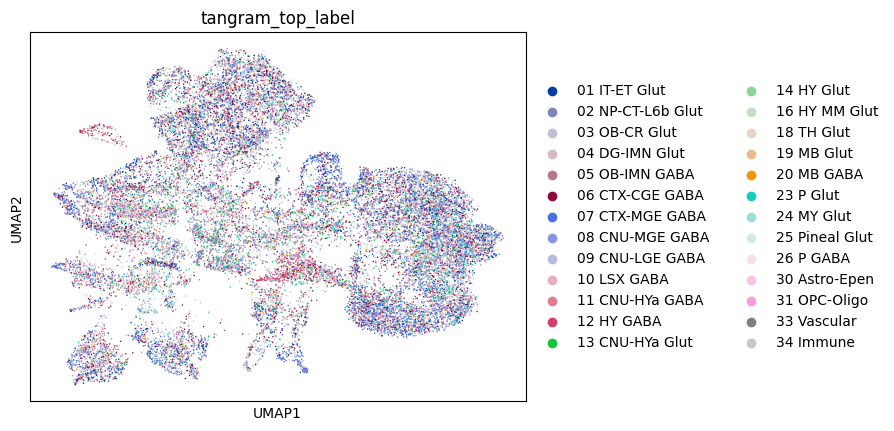

In [114]:
sc.pl.umap(ad_sp, color = 'tangram_top_label')

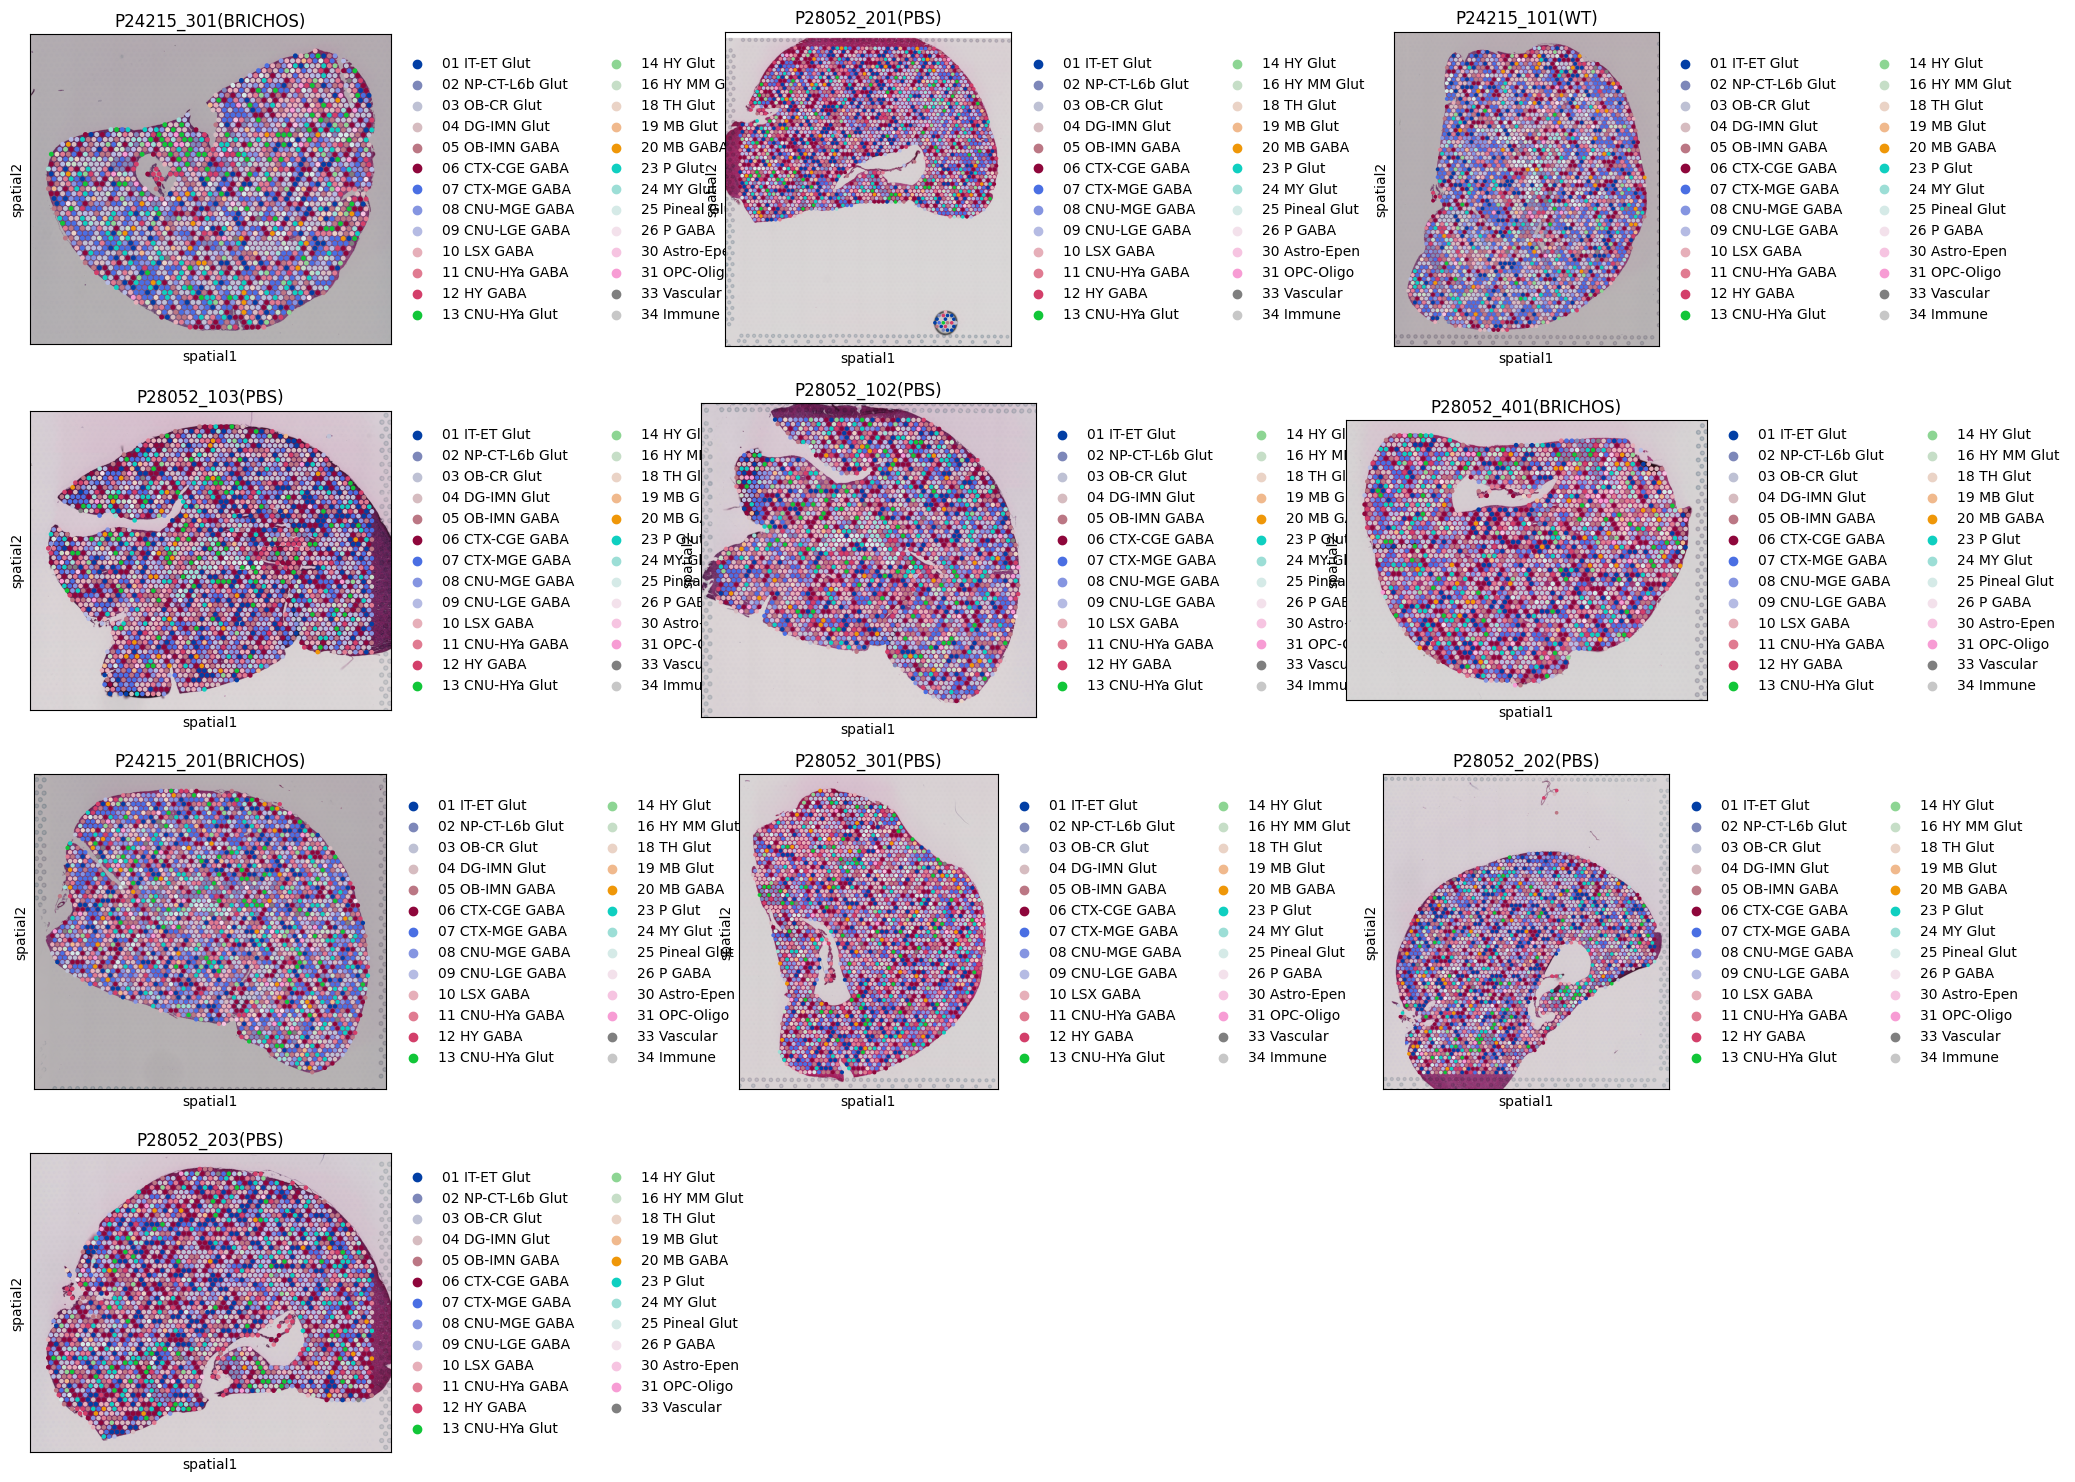

In [118]:
plot_spatial_clusters_per_sample(ad_sp, color = 'tangram_top_label', figsize=(20,15))